In [15]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error 
from scipy.stats import normaltest, skew, boxcox

In [16]:
sns.set_style('darkgrid')

In [17]:
df = pd.read_csv('data/Country.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [18]:
df.drop(
    columns=['country'],
    axis=1,
    inplace=True
)

df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [19]:
df.isnull().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
Gdpp          0
dtype: int64

In [20]:
df.dtypes.to_frame(name='dtype')

,dtype
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
Gdpp,int64


In [21]:
df.duplicated().sum()

0

In [22]:
df.nunique().sort_values()

life_expec    127
total_fer     138
child_mort    139
exports       147
health        147
imports       151
income        156
inflation     156
Gdpp          157
dtype: int64

In [23]:
df.shape

(167, 9)

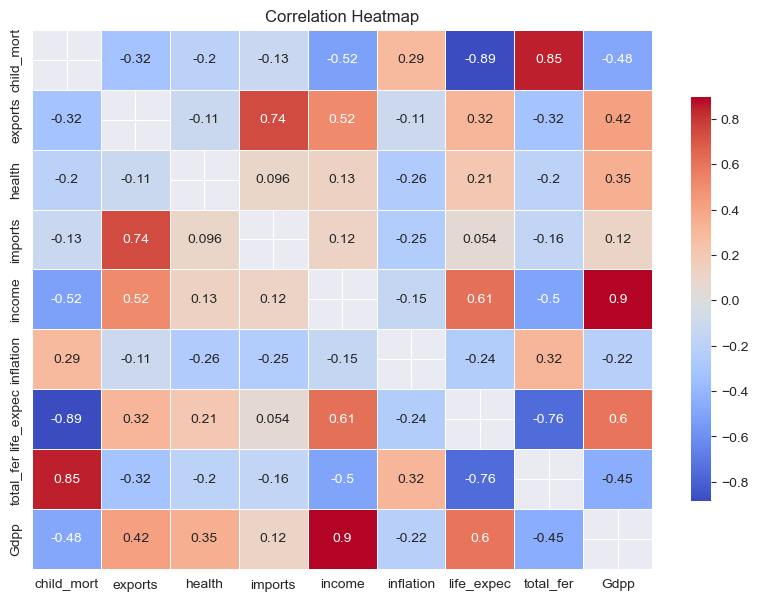

In [24]:
corr = df.corr()

np.fill_diagonal(corr.values, np.nan)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink': 0.75
    }
)

plt.title('Correlation Heatmap')
plt.show()

In [25]:
# VIF (Variance Inflation Factor)

# Feature data set oluşturalım
X_features = df.drop(columns=['Gdpp'])

# VIF Tablosu
vif_data = pd.DataFrame()
vif_data['feature'] = X_features.columns
vif_data['VIF Score'] = [
    variance_inflation_factor(X_features.values, i)
    for i in range(len(X_features.columns))
]

vif_data.sort_values(by='VIF Score', ascending=False)

,feature,VIF Score
6,life_expec,20.033757
7,total_fer,17.652689
3,imports,17.078102
1,exports,16.008933
2,health,9.832297
0,child_mort,8.060881
4,income,4.282023
5,inflation,1.942327
